### Lab 4: Regression and Classification Evaluation Metrics

#### Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

#### Aim
To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

#### Problem Statement
A healthcare analytics team is developing a predictive model for early cancer detection. You are required to build a KNN classifier, optimize its performance using different validation techniques, and compare classification evaluation metrics with regression evaluation metrics from Lab 3.




In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

#### Task 1: Data Preparation


**1. Load the dataset**

In [2]:
data = pd.read_csv("brca.csv")

**2. Convert into DataFrame and explore structure.**

In [6]:
# looking at the first 5 rows of the dataset

data.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [7]:
# looking at the shape of the dataset

print("Shape:", data.shape)

Shape: (569, 32)


In [8]:
# oberving the data types and null values in the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

In [10]:
# drop id column because it is unneccessary and repititive

data.drop("Unnamed: 0", axis=1, inplace=True)

**3. Check missing values and duplicates.**

In [11]:
print(data.isnull().sum())

x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64


No missing values in the datset

In [12]:
# checking for duplicate values

print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


No duplicate values in the datset

In [13]:
# checking the distribution of the target variable

print(data['y'].value_counts())

y
B    357
M    212
Name: count, dtype: int64


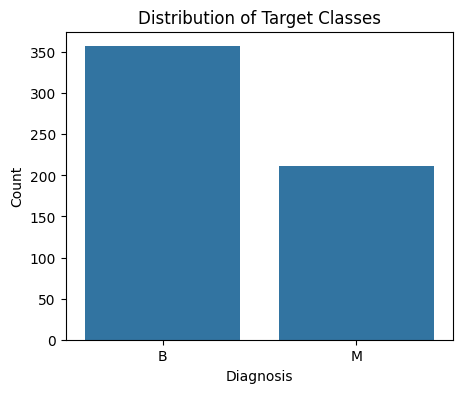

In [14]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='y',
    data=data
)

plt.title("Distribution of Target Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

In [15]:
# encode target variable

data['y'] = data['y'].map({
    'M': 0,
    'B': 1
})

KNN cannot work directly with string labels like 'B' and 'M'. We convert them to numerical values while preserving their meaning.

In [16]:
#  seperate features and target variable

X = data.drop('y', axis=1)
y = data['y']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (569, 30)
y Shape: (569,)


**4. Apply feature scaling using StandardScaler and justify its importance.**

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Importance of Feature Scaling

Feature scaling was performed using **StandardScaler** because K-Nearest Neighbours is a **distance-based algorithm**. Features in the dataset have different ranges, and without scaling, variables with larger numerical values would dominate the distance calculation. Standardization transforms each feature to have a mean of 0 and a standard deviation of 1, ensuring that all features contribute equally to the distance computation.

#### Task 2: Train-Test Split Analysis


**1. Split dataset into training and testing sets (80:20).**

**2. Repeat with 70:30 and 90:10 splits.**

In [18]:
# 80 : 20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 70 : 30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 90 : 10
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X_scaled,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

In [19]:
print("80:20")
print("Train:", X_train_80.shape)
print("Test :", X_test_80.shape)

print("\n70:30")
print("Train:", X_train_70.shape)
print("Test :", X_test_70.shape)

print("\n90:10")
print("Train:", X_train_90.shape)
print("Test :", X_test_90.shape)

80:20
Train: (455, 30)
Test : (114, 30)

70:30
Train: (398, 30)
Test : (171, 30)

90:10
Train: (512, 30)
Test : (57, 30)


Train-Test Split

The dataset was divided into training and testing sets using three different ratios: **80:20**, **70:30**, and **90:10**. Stratified sampling was used to preserve the proportion of benign and malignant cases in each split. This allows a fair comparison of model performance under different training data sizes and helps analyze model stability and generalization.

#### Task 3: KNN Model with Heuristic K Selection

##### 3.1 Heuristic Method for K Selection



In [20]:
n = len(X_train_80)

heuristic_k = int(np.sqrt(n))

# Make K odd (avoids ties)
if heuristic_k % 2 == 0:
    heuristic_k += 1

print("Training Samples:", n)
print("Heuristic K:", heuristic_k)

Training Samples: 455
Heuristic K: 21


Heuristic Selection of K

The initial value of K was selected using the heuristic rule:

K = √n

where n is the number of training samples.

For the 80:20 train-test split, the training set contained 455 samples.

√455 ≈ 21.33

Therefore, the nearest odd integer, **K = 21**, was selected as the baseline value. An odd value of K is preferred in binary classification to reduce the possibility of tie votes.

##### 3.2 Model Training

**1. Train KNN classifier using heuristic K value.**

In [21]:
# Create the model
knn = KNeighborsClassifier(n_neighbors=heuristic_k)

# Train the model
knn.fit(X_train_80, y_train_80)

,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
y_pred_21 = knn.predict(X_test_80)

In [23]:
accuracy_21 = accuracy_score(y_test_80, y_pred_21)

print("Heuristic K:", heuristic_k)
print("Accuracy:", accuracy_21)

Heuristic K: 21
Accuracy: 0.956140350877193


Baseline KNN Model

A K-Nearest Neighbours classifier was trained using the heuristic value **K = 21**. The model was evaluated on the test set using **Accuracy**, which serves as the baseline performance before experimenting with other K values.

**2. Experiment with nearby values of K (K ± 5).**

In [24]:
k_values = range(16, 27)

accuracies = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_80, y_train_80)

    y_pred = model.predict(X_test_80)

    acc = accuracy_score(y_test_80, y_pred)
    accuracies.append(acc)

    print(f"K = {k:2d}  Accuracy = {acc:.4f}")

K = 16  Accuracy = 0.9737
K = 17  Accuracy = 0.9737
K = 18  Accuracy = 0.9825
K = 19  Accuracy = 0.9737
K = 20  Accuracy = 0.9649
K = 21  Accuracy = 0.9561
K = 22  Accuracy = 0.9561
K = 23  Accuracy = 0.9649
K = 24  Accuracy = 0.9561
K = 25  Accuracy = 0.9649
K = 26  Accuracy = 0.9561


**3. Plot accuracy vs K values.**

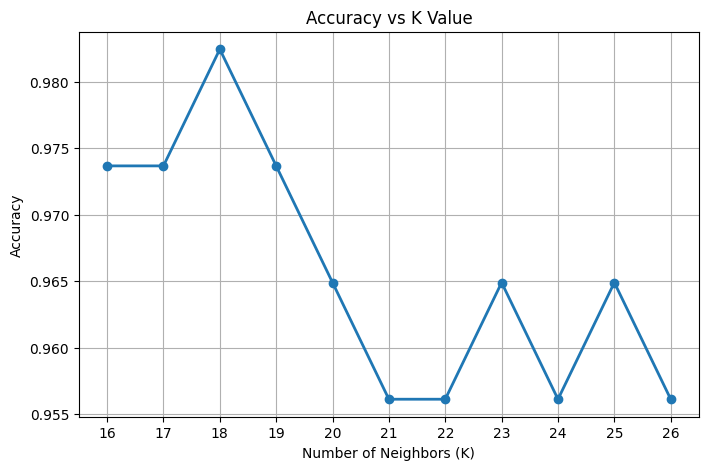

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker='o',
    linewidth=2
)

plt.title("Accuracy vs K Value")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.xticks(k_values)

plt.grid(True)

plt.show()

**4. Identify optimal K based on performance trend.**

In [25]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 18
Best Accuracy: 0.9824561403508771


Accuracy vs K Analysis

The KNN classifier was trained using values of K ranging from **16 to 26** (K ± 5 around the heuristic value). The corresponding accuracies were plotted to observe the performance trend. The value of K that produced the highest accuracy was selected as the optimal K for the final model.

##### 3.3 Distance Matrix and Decision Boundary Mapping 

**1. Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.**

--- 
**Euclidean Distance**

Euclidean distance is the straight-line distance between two data points in a multidimensional space.

Formula:

d = √((x₁ − y₁)² + (x₂ − y₂)² + ... + (xₙ − yₙ)²)

Suitable when:
- Features are continuous.
- Data is properly standardized.
- Straight-line distance accurately represents similarity.


**Manhattan Distance**

Manhattan distance is the sum of the absolute differences between corresponding feature values.

Formula:

d = |x₁ − y₁| + |x₂ − y₂| + ... + |xₙ − yₙ|

**Suitable when:**
- Data contains outliers.
- Grid-like movement is more appropriate.
- Absolute differences are preferred over squared differences.

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [28]:
X_pca = pca.fit_transform(X_scaled)

In [29]:
print("Original Shape :", X_scaled.shape)
print("Reduced Shape  :", X_pca.shape)

Original Shape : (569, 30)
Reduced Shape  : (569, 2)


In [30]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.44272026 0.18971182]

Total Variance Explained:
0.6324320765155944


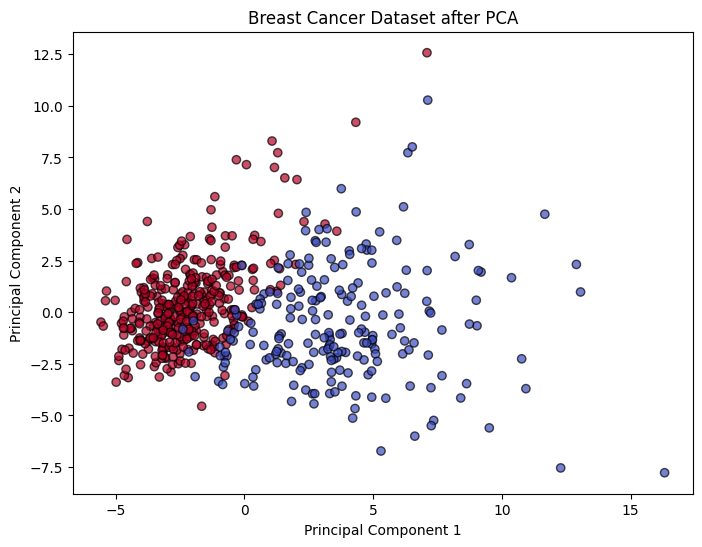

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='coolwarm',
    edgecolor='k',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Dataset after PCA")

plt.show()

Principal Component Analysis (PCA)

Since the Breast Cancer dataset contains **30 features**, it is impossible to directly visualize the decision boundary in such a high-dimensional space.

Principal Component Analysis (PCA) was applied to reduce the dataset to **two principal components** while preserving most of the information. These two components were then used for visualization of the KNN decision boundaries.

In [32]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, k, ax):

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap=ListedColormap(["#FF9999", "#99CCFF"])
    )

    ax.scatter(
        X[:,0],
        X[:,1],
        c=y,
        edgecolor='k',
        cmap='coolwarm'
    )

    ax.set_title(f"KNN Decision Boundary (K = {k})")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

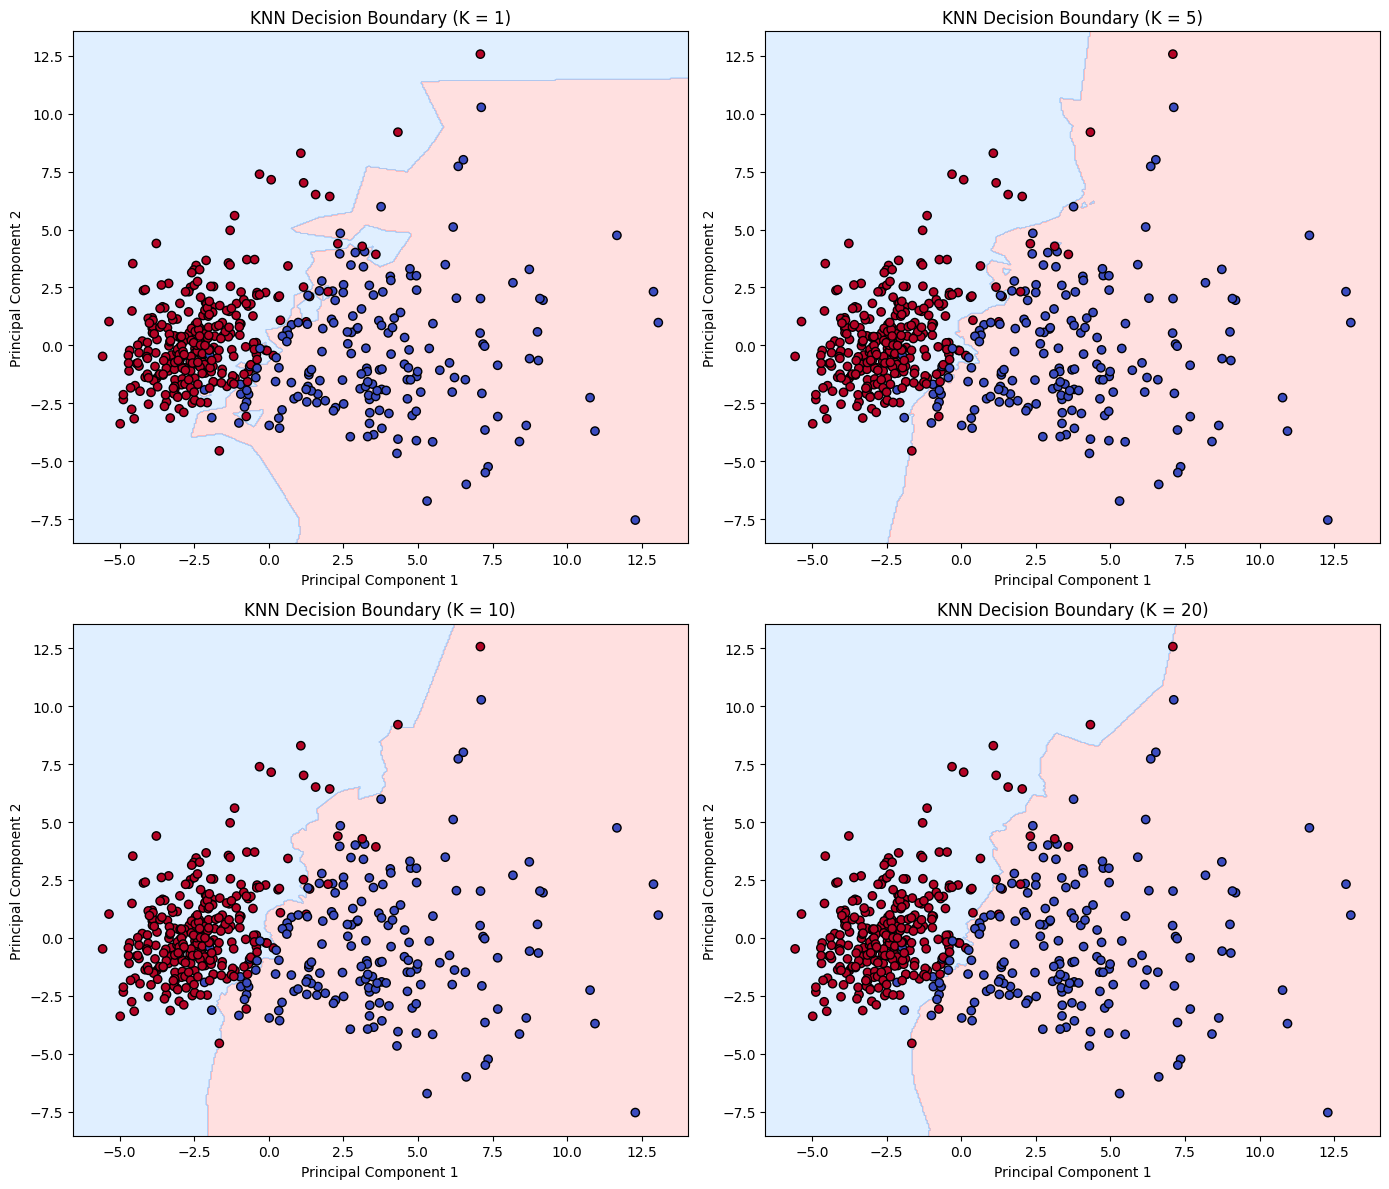

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_decision_boundary(X_train_pca, y_train_pca, 1, axes[0, 0])
plot_decision_boundary(X_train_pca, y_train_pca, 5, axes[0, 1])
plot_decision_boundary(X_train_pca, y_train_pca, 10, axes[1, 0])
plot_decision_boundary(X_train_pca, y_train_pca, 20, axes[1, 1])

plt.tight_layout()
plt.show()

Analysis of Decision Boundary

The decision boundary changes significantly as the value of **K** increases.

- **K = 1:** The boundary is highly irregular and closely follows the training samples. The model is sensitive to noise and may overfit the data.
- **K = 5:** The boundary becomes smoother, reducing the effect of noisy observations while maintaining good classification performance.
- **K = 10:** The boundary is smoother and more stable, providing a good balance between model complexity and generalization.
- **K = 20:** The decision boundary becomes very smooth and less flexible. Although the model is more robust to noise, it may oversimplify the data distribution, leading to underfitting.

Overall, increasing **K** decreases model variance and increases bias. Therefore, selecting an appropriate value of **K** is essential to achieve the best balance between overfitting and underfitting.

#### Task 4: Cross Validation


In [38]:
k_values = range(16, 27)

cv_mean_accuracy = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5,
        scoring='accuracy'
    )

    cv_mean_accuracy.append(scores.mean())

    print(f"K = {k:2d} | Mean Accuracy = {scores.mean():.4f} | Std = {scores.std():.4f}")

K = 16 | Mean Accuracy = 0.9666 | Std = 0.0151
K = 17 | Mean Accuracy = 0.9596 | Std = 0.0119
K = 18 | Mean Accuracy = 0.9596 | Std = 0.0142
K = 19 | Mean Accuracy = 0.9543 | Std = 0.0140
K = 20 | Mean Accuracy = 0.9543 | Std = 0.0178
K = 21 | Mean Accuracy = 0.9526 | Std = 0.0162
K = 22 | Mean Accuracy = 0.9543 | Std = 0.0178
K = 23 | Mean Accuracy = 0.9543 | Std = 0.0178
K = 24 | Mean Accuracy = 0.9561 | Std = 0.0156
K = 25 | Mean Accuracy = 0.9543 | Std = 0.0178
K = 26 | Mean Accuracy = 0.9526 | Std = 0.0196


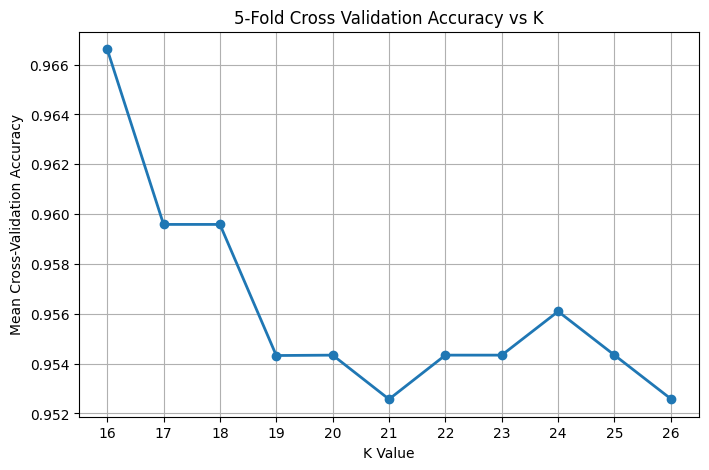

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    cv_mean_accuracy,
    marker='o',
    linewidth=2
)

plt.xlabel("K Value")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("5-Fold Cross Validation Accuracy vs K")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [40]:
best_cv_k = k_values[np.argmax(cv_mean_accuracy)]
best_cv_accuracy = max(cv_mean_accuracy)

print("Best K (Cross Validation):", best_cv_k)
print("Best Mean Accuracy:", best_cv_accuracy)

Best K (Cross Validation): 16
Best Mean Accuracy: 0.9666200900481291


Cross-Validation Analysis

Five-fold cross-validation was performed for K values ranging from **16 to 26**.

The highest mean cross-validation accuracy (**96.66%**) was obtained at **K = 16**. Although the train-test split produced a higher accuracy (**98.25%**) for **K = 18**, cross-validation is considered more reliable because it evaluates the model across multiple train-test partitions rather than relying on a single split.

Therefore, **K = 16** was selected as the final value since it demonstrated the best average performance and better generalization capability.

**Compare cross-validation results with train-test split results.**


* The train-test split gave the highest accuracy (98.25%), but that's on one particular split of the data.
* Cross-validation evaluates the model on five different splits, so its accuracy (96.66%) is a more reliable estimate of real-world performance.
* The heuristic K (21) provided a good starting point, but experimentation found better values.*

| Method                  | Best K |   Accuracy |
| ----------------------- | -----: | ---------: |
| Heuristic (√n)          |     21 |     95.61% |
| Train-Test Split        | **18** | **98.25%** |
| 5-Fold Cross Validation | **16** | **96.66%** |


#### Task 5: Classification Evaluation

**Evaluate final model using:**
* Accuracy
* Precision
* Recall
* F1 Score

In [41]:
# training the final model with k = 16 (best k from cross-validation)

final_knn = KNeighborsClassifier(n_neighbors=16)

final_knn.fit(X_train_80, y_train_80)

y_pred_final = final_knn.predict(X_test_80)

In [42]:
accuracy = accuracy_score(y_test_80, y_pred_final)
precision = precision_score(y_test_80, y_pred_final)
recall = recall_score(y_test_80, y_pred_final)
f1 = f1_score(y_test_80, y_pred_final)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9736842105263158
Precision: 0.9726027397260274
Recall   : 0.9861111111111112
F1 Score : 0.9793103448275862


* Confusion Matrix


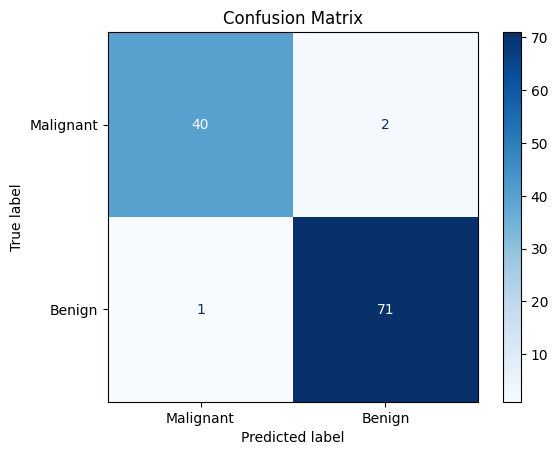

In [43]:
cm = confusion_matrix(y_test_80, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

* Classification report

In [44]:
print(classification_report(
    y_test_80,
    y_pred_final,
    target_names=["Malignant","Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        42
      Benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



* ROC Curve and AUC Score

In [45]:
y_prob = final_knn.predict_proba(X_test_80)[:, 1]

In [47]:
fpr, tpr, thresholds = roc_curve(y_test_80, y_prob)

auc_score = roc_auc_score(y_test_80, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.9930555555555556


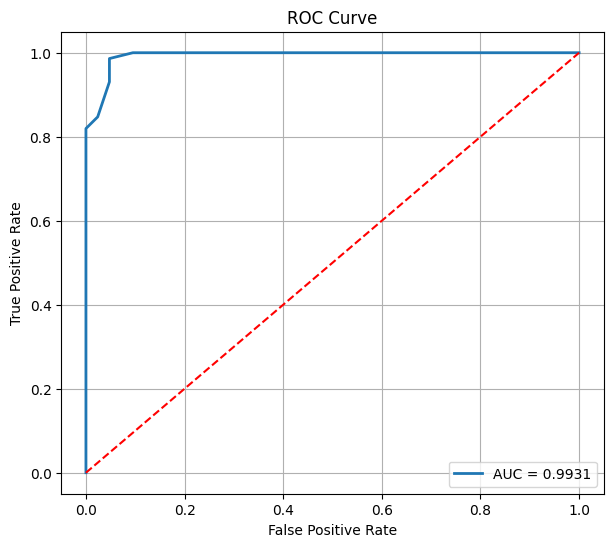

In [48]:
plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

#### Task 6: Comparative Study with Regression (Lab 3 Integration)

1. Comparison Table

| Regression Evaluation Metrics (Lab 3) | Classification Evaluation Metrics (Lab 4) |
| ------------------------------------- | ----------------------------------------- |
| MAE (Mean Absolute Error)             | Accuracy                                  |
| MSE (Mean Squared Error)              | Precision                                 |
| RMSE (Root Mean Squared Error)        | Recall                                    |
| R² Score                              | F1 Score                                  |
| Measures prediction error             | Measures classification performance       |
| Used for continuous values            | Used for categorical labels               |


2. Error-based Evaluation vs Decision-based Evaluation

**Error-based Evaluation (Regression)**

Used when the output is a continuous numerical value.
Measures how far the predicted value is from the actual value.
Lower error indicates a better model.

Examples:
* MAE
* MSE
* RMSE
* R² Score

**Decision-based Evaluation (Classification)**

Used when the output belongs to a class/category.
Measures whether the prediction is correct or incorrect.
Evaluates class-wise performance.

Examples:

* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC

3. Compare: 

- R² Score vs Accuracy

| R² Score                                            | Accuracy                                            |
| --------------------------------------------------- | --------------------------------------------------- |
| Used in regression                                  | Used in classification                              |
| Measures how well predictions explain data variance | Measures percentage of correctly classified samples |
| Range: (-∞, 1]                                      | Range: 0–1                                          |
| Higher is better                                    | Higher is better                                    |

- RMSE vs F1 Score

| RMSE                              | F1 Score                      |
| --------------------------------- | ----------------------------- |
| Regression metric                 | Classification metric         |
| Measures average prediction error | Balances Precision and Recall |
| Lower is better                   | Higher is better              |


- MAE vs Confusion Matrix

| MAE                             | Confusion Matrix                      |
| ------------------------------- | ------------------------------------- |
| Average prediction error        | Counts TP, TN, FP, FN                 |
| Gives one numerical error value | Gives detailed classification results |
| Regression                      | Classification                        |


4. Discuss differences in evaluation logic for:

**Continuous prediction tasks**

* Predicts numerical values.

* Examples: House price, GPA, Salary

* Evaluation: MAE, MSE, RMSE, R²

**Classification**

* Predicts categories.
* Examples: Benign/Malignant, Spam/Not Spam, Pass/Fail
* Evaluation: Accuracy, Precision, Recall, F1 Score, ROC-AUC


#### Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**

KNN is called a lazy learning algorithm because it does not build a model during training. Instead, it stores the training data and performs all computations only when a new data point needs to be classified.

**2. Why is feature scaling required in KNN?**

KNN uses distance calculations to identify nearest neighbors. Features with larger numerical values dominate the distance computation if scaling is not performed. Standardization ensures that all features contribute equally.

**3. Explain heuristic K selection using √n rule.**

The heuristic √n rule is a commonly used guideline for selecting the initial value of K in the K-Nearest Neighbours (KNN) algorithm, where n is the number of training samples.

The square root provides a balanced starting point by preventing K from being too small or too large. A small K makes the model highly sensitive to noise and can lead to overfitting, while a large K oversmooths the decision boundary and may result in underfitting.

For binary classification problems, K is usually chosen as an odd number to avoid ties during majority voting. The √n rule is only a heuristic, meaning it provides an initial estimate rather than the optimal value. The final value of K should be determined experimentally using techniques such as cross-validation or validation accuracy.

**4. Why is cross-validation more reliable than a single train-test split?**

Cross-validation evaluates the model on multiple train-test partitions instead of relying on a single split. This reduces the effect of random sampling and provides a more reliable estimate of the model's generalization performance.

**5. How does K affect bias-variance trade-off?**

|K Value | Model Complexity | Bias | Variance | Fit Type | Description|
| -----------|----------|---------- | -----------|-----------|--------------- |
|Small (e.g., K=1) | High | Low | High | Overfitting| The model learns the training data too strictly, including random noise, resulting in erratic predictions.|
|Large (e.g., K=N) | Low | High | Low | Underfitting | The model oversimplifies by relying on global averages. It fails to capture important local patterns.|


**6. Why is recall more important than accuracy in cancer prediction?**

In medical diagnosis, failing to detect a malignant tumor (false negative) can have serious consequences. Recall measures the proportion of actual positive cases correctly identified, making it more important than overall accuracy for cancer detection.

**What is the limitation of very large K values?**

A very large K considers too many neighbors, causing the classifier to ignore local patterns. This leads to an overly smooth decision boundary and may result in underfitting.
